In [8]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import matplotlib as mpl

from plotting_functions import (
    plot_array_hist_over_time, 
    plot_residual_sequences, 
    plot_bin_borders_onto_residuals,
    plot_daily_time_series,
    )


In [9]:
mpl.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "savefig.dpi": 600,
})

In [10]:
experiment_name = 'lin_reg'
data_dir = Path(f"indicator_data/{experiment_name}")

data = []

for file in os.listdir(data_dir):
    df = pd.read_csv(data_dir / file)
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    
    data += [df]


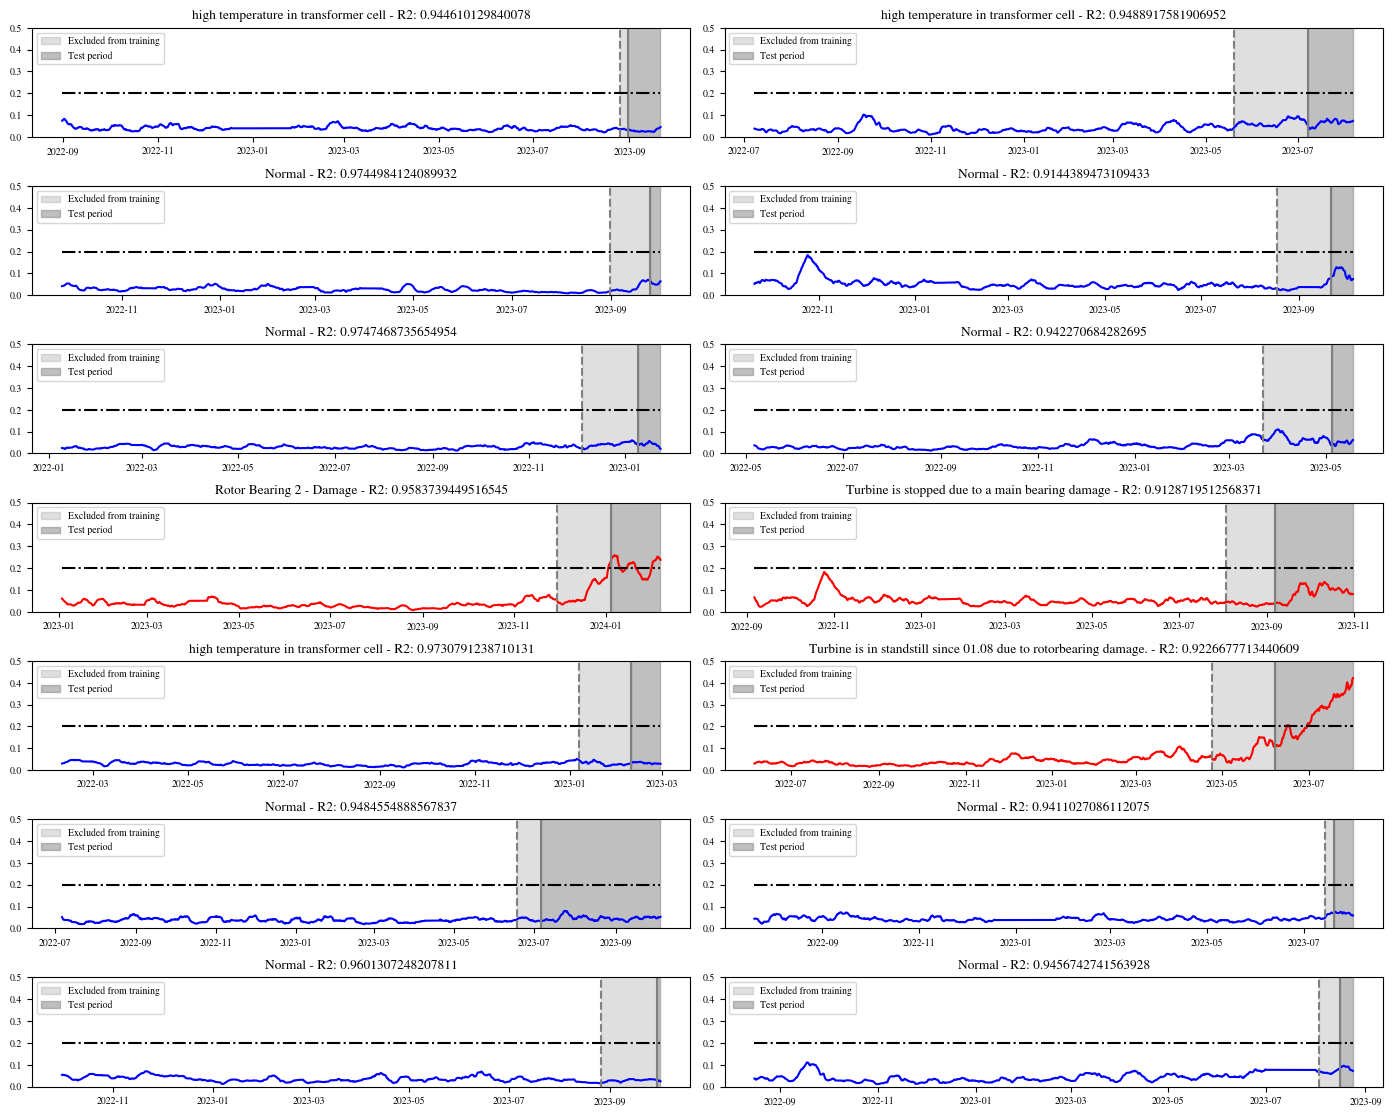

Rejected 1 / 15


In [11]:
window = 6 * 24 * 7
n_rejected = 0
threshold = 0.2

fig, ax = plt.subplots(7, 2, figsize=(14, 1.6 * 7))

for k, df in enumerate(data):
    x = pd.to_datetime(df.time_stamp[window-1:]).to_numpy()
    y = np.convolve(df.residual, np.ones(window)/window, mode='valid')
    cutoff = df['training_cutoff'].iloc[0]
    test_start = df['test_period_start'].iloc[0]

    score = r2_score(df.target[:cutoff], df.predictions[:cutoff])
    if score < 0.2:
        # Reject models that did not fit well enough!
        n_rejected += 1
        continue
    


    label = df['label'].iloc[0]
    color = 'blue'
    if label == 'anomaly':
        color = 'red'

    title = df.description.iloc[0]
    if isinstance(title, float):
        title = 'Normal'

    i, j = (k - n_rejected) // 2, (k - n_rejected) % 2

    ax[i,j].step(x, y, color=color)
    ax[i,j].set_title(title + ' - R2: ' + str(score))
    ax[i,j].vlines(x[cutoff], 0, 1, 'gray', linestyles='dashed')
    ax[i,j].vlines(x[test_start], 0, 1, 'gray', linestyles='solid')
    ax[i,j].fill_betweenx([0,1], x[cutoff], x[test_start], color='gray', alpha=0.25, label='Excluded from training')
    ax[i,j].fill_betweenx([0,1], x[test_start], x[-1], color='gray', alpha=0.5, label='Test period')

    ax[i,j].plot([x[0], x[-1]], [threshold]*2, 'k-.')
    ax[i,j].set_ylim(0,0.5)
    ax[i,j].legend()

plt.tight_layout()
plt.show()
print('Rejected', n_rejected, '/', len(data))

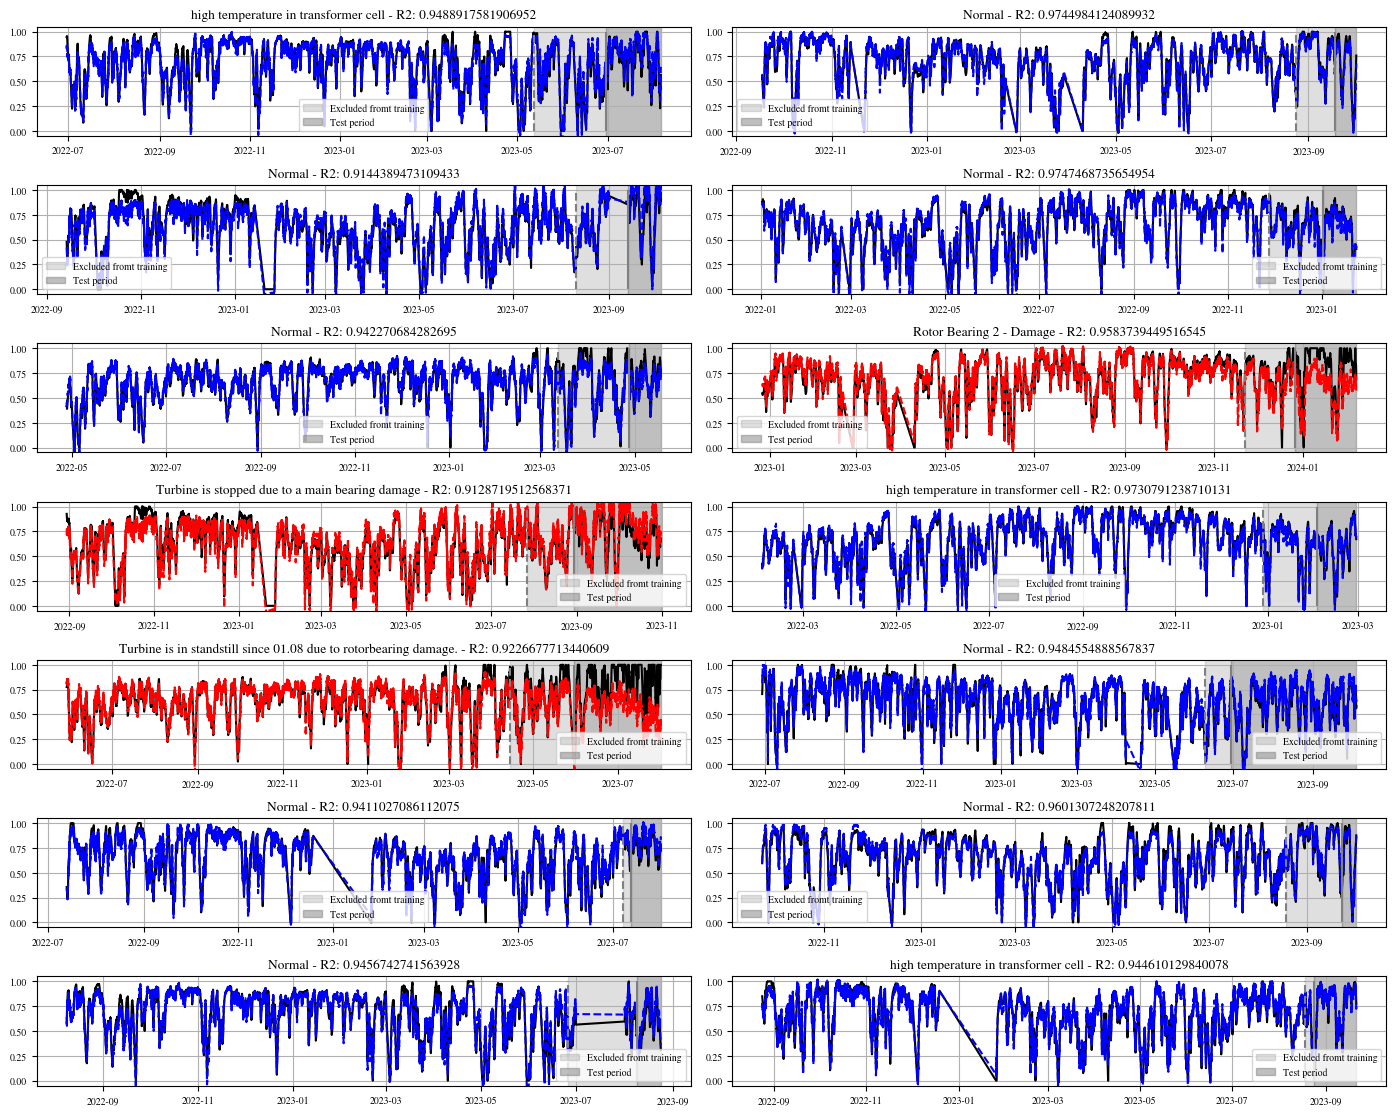

In [12]:
good_data = []

fig, ax = plt.subplots(7, 2, figsize=(14, 1.6 * 7))


for k, df in enumerate(data):
    x = pd.to_datetime(df.time_stamp).to_numpy()
    y = np.convolve(df.residual, np.ones(window)/window, mode='valid')
    cutoff = df['training_cutoff'].iloc[0]
    test_start = df['test_period_start'].iloc[0]

    score = r2_score(df.target[:cutoff], df.predictions[:cutoff])
    if score < 0.2:
        # Reject models that did not fit well enough!
        n_rejected += 1
        continue

    else:
        good_data.append(df)

    label = df['label'].iloc[0]
    color = 'blue'
    if label == 'anomaly':
        color = 'red'

    title = df.description.iloc[0]
    if isinstance(title, float):
        title = 'Normal'

    i, j = (k - n_rejected) // 2, (k - n_rejected) % 2
    
    ax[i,j].plot(x, df.target, color='black')
    ax[i,j].plot(x, df.predictions, color=color, linestyle='dashed')
    ax[i,j].set_title(title + ' - R2: ' + str(score))
    ax[i,j].vlines(x[cutoff], 0, 1, 'gray', linestyles='dashed')
    ax[i,j].vlines(x[test_start], 0, 1, 'gray', linestyles='solid')
    ax[i,j].fill_betweenx([-1,2], x[cutoff], x[test_start], color='gray', alpha=0.25, label='Excluded fromt training')
    ax[i,j].fill_betweenx([-1,2], x[test_start], x[-1], color='gray', alpha=0.5, label='Test period')
    ax[i,j].grid()
    ax[i,j].set_ylim(-0.05,1.05)
    ax[i,j].legend()

plt.tight_layout()
plt.show()

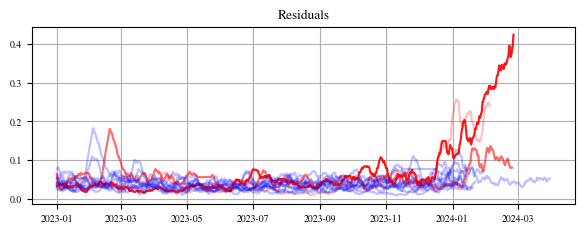

In [13]:
# Sliding window averages of the residuals

fig, ax = plot_residual_sequences(good_data)
fig.set_size_inches(7, 2.3)
plt.show()

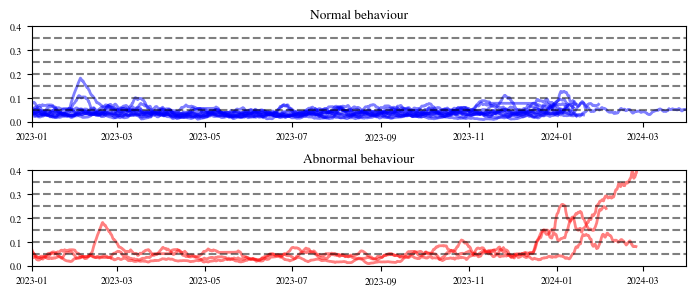

In [14]:
# Discretization borders for the observations

bin_borders = np.linspace(0.05,.35, 7)
fig, ax = plot_bin_borders_onto_residuals(good_data, bin_borders)

fig.set_size_inches(7, 3)
plt.tight_layout()
plt.show()

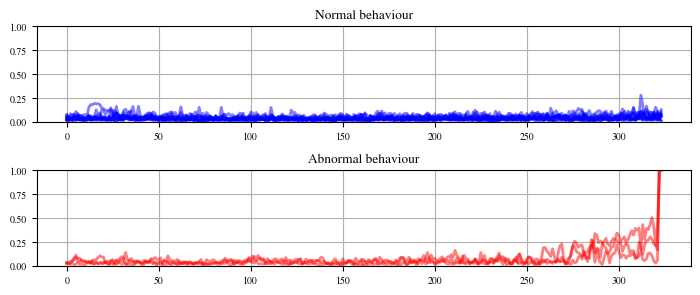

In [15]:
# Daily averaging and preprocessing of the sequences

daily_time_series = []
batch_size = 6 * 24
max_len = 324

for df in good_data:
    ys = df["residual"].to_numpy()
    ys_batched = np.convolve(ys, np.ones(batch_size)/batch_size, mode='valid')[::batch_size]
    if df['label'].iloc[0] != 'normal':
        ys_batched = np.concat([ys_batched, [1.0, 1.0]])
    ys_batched = ys_batched[-max_len:]
    daily_time_series.append(ys_batched)

daily_time_series = np.array(daily_time_series)

fig, ax = plot_daily_time_series(daily_time_series)
fig.set_size_inches(7, 3)
plt.tight_layout()
plt.show()

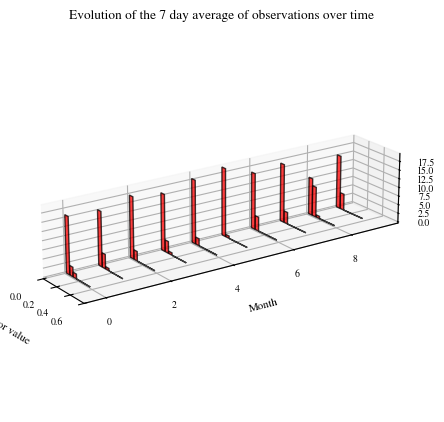

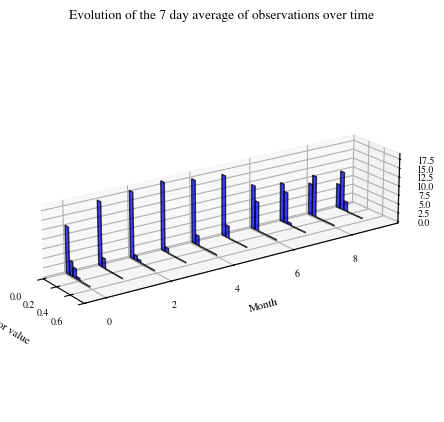

In [20]:
# Inspection of the emissions over time

bins = np.linspace(0,.35, 8)

fig, ax = plot_array_hist_over_time(daily_time_series[10], 'red', bins)
fig.set_size_inches(7, 5)
plt.show()

fig, ax = plot_array_hist_over_time(daily_time_series[1], 'blue', bins)
fig.set_size_inches(7, 5)
plt.show()

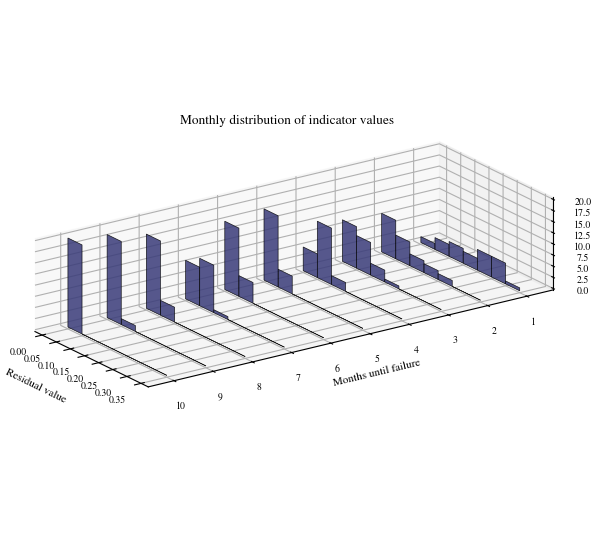

In [120]:

cmap = plt.cm.tab20b

colors = cmap.colors

def plot_hists(
        distr_data: np.ndarray, 
        color: str, 
        bins: np.ndarray, 
        name=None, 
        interval: int = 30) -> tuple:


    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(projection='3d')
    ax.set_proj_type('ortho')
    ax.view_init(20,-35, 0)
    ax.set_box_aspect([2, 5, 1])

    yticks = np.arange(len(distr_data) // interval)


    ks = range(len(yticks))

    for window_start, k in zip(yticks, ks):
        window_start = interval * window_start

        ys, xs = np.histogram(distr_data[window_start: window_start + interval], bins, density=True)

 
        # Plot the bar graph given by xs and ys on the plane y=k
        ax.bar(xs[1:] - 0.025 , ys, width=xs[1] - xs[0], zs=k, zdir='y', color=color, alpha=0.85, edgecolor='black', linewidth=.5)

    ax.set_xlabel('Residual value', labelpad=6)
    ax.set_ylabel('Months until failure', labelpad=24)
    ax.set_zlabel('Density', labelpad=0)

    # On the y-axis let's only label the discrete values that we have data for.
    ax.set_yticks(ks[::], ['\n' + str(10 - y) for y in yticks[::]])
    ax.set_xticks(np.linspace(0.00, 0.35, 8, endpoint=True))
    ax.set_title(
        "Monthly distribution of indicator values",
        pad=0,
        y=0.85
    )

    # Manually position the axes inside the canvas
    ax.set_position([0.08, 0.15, 0.9, 0.75])

    # Force a draw so Matplotlib computes text extents
    # fig.canvas.draw()

    # # Get the tight bounding box
    # bbox = fig.get_tightbbox(fig.canvas.get_renderer())

    if name is not None:
        plt.savefig(
            f'plots/{name}.pdf', 
            dpi=600, 
            bbox_inches=mpl.transforms.Bbox(
                np.array([[1.0,2.2], [8,5.35]])))

    return fig, ax

plot_hists(daily_time_series[9], colors[0], bins, name='histograms')
plt.show()